# AIMD Cache Pareto and Convergence Evaluation

This notebook demonstrates the evaluation logic in `eval.py`, which compares four caching policies for LLM tool calls in an agent loop—**AIMD** (additive-increase/multiplicative-decrease, TCP-style), **fixed-TTL**, **d-TTL** (adaptive TTL), and **FreshCache-gate** (calibrated staleness-probability gate)—on a per-call event log.

Given a log of individual cache-relevant calls (one row per call, with which policy/knob served it, whether it was served from cache, and whether a spot-check later confirmed it was stale), the script computes:

1. **Operating points** — cache-hit-fraction vs. staleness-rate per (policy, knob, volatility regime), with episode-level bootstrap 95% CIs (raw spot-checked and inverse-probability-reweighted).
2. **Pareto frontiers** — non-dominated (hit-fraction, staleness) points per regime, frontier-AUC, AIMD-vs-baseline dominance fractions, and matched-staleness-target hit-fraction comparisons.
3. **Convergence / sample efficiency** — a uniform tolerance-band stabilization definition (±10%, 10 consecutive updates) applied to each policy's adapted control value, aggregated by call-site repeat-count bucket (low/medium/high), including failure-to-converge rates.
4. **Statistical tests** — paired Wilcoxon/bootstrap tests with Holm-Bonferroni correction and effect sizes.
5. **A mechanical CONFIRMS/DISCONFIRMS verdict** against the hypothesis's two stated success criteria.
6. **Robustness checks** — spot-check-rate sensitivity, volatility/repeat-count confound table, FreshCache calibration (Brier score, reliability diagram), missingness reporting.

**Note on the data:** the real upstream experiment run for this artifact produced no per-call event log (the eval detected `BLOCKED_NO_DATA` and, honestly, reported that rather than fabricating numbers — see `preview_eval_out.json`). To demonstrate the evaluation logic itself, this notebook runs the *exact same* `eval.py` analysis functions against a small **synthetic** per-call event log (`mini_demo_data.json`) built to match the schema `eval.py` expects. The numbers below are therefore illustrative of the method, not a real experimental finding.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, scipy, matplotlib are pre-installed on Colab; install locally to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import logging
import sys

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    stream=sys.stdout,
)
log = logging.getLogger("eval")

## Load the per-call event log

`mini_demo_data.json` is a small synthetic per-call event log built to match the exact schema `eval.py`'s `run_full_evaluation` expects: `episode_id`, `seed`, `volatility_regime`, `call_site_id`, `timestamp`, `policy_name`, `knob_value`, `served_from_cache`, `spot_checked`, `ground_truth_stale`, plus a per-update `current_adapted_value` field (the policy's internal control value — AIMD's window, d-TTL's adapted TTL, or FreshCache's calibrated staleness probability). We fetch it from GitHub with a local-file fallback so this notebook works both standalone and on Colab.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a08cec-does-tcp-style-reactive-caching-actually/main/round-1/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL, timeout=10) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
df_raw = pd.DataFrame(data)
print(f"loaded {len(df_raw)} rows, {df_raw['episode_id'].nunique()} episodes, policies={sorted(df_raw['policy_name'].unique())}")
df_raw.head()

loaded 1351 rows, 32 episodes, policies=['aimd', 'd_ttl', 'fixed_ttl', 'freshcache_gate']


,episode_id,seed,volatility_regime,call_site_id,timestamp,policy_name,knob_value,served_from_cache,spot_checked,ground_truth_stale,current_adapted_value
0,ep_low_volatility_aimd_4_0,0,low_volatility,site_0,0,aimd,4.0,False,False,None,5.0
1,ep_low_volatility_aimd_4_0,0,low_volatility,site_0,1,aimd,4.0,True,True,False,6.0
2,ep_low_volatility_aimd_4_0,0,low_volatility,site_0,2,aimd,4.0,True,True,False,7.0
3,ep_low_volatility_aimd_4_0,0,low_volatility,site_0,3,aimd,4.0,True,False,None,8.0
4,ep_low_volatility_aimd_4_0,0,low_volatility,site_0,4,aimd,4.0,True,True,False,9.0


## Configuration

These are the same tunable constants defined at the top of `eval.py`. `BOOTSTRAP_N` is reduced from the original 2000 to 200 to keep the demo fast — increase it back to 2000 for a full run (the CIs get tighter/more accurate but the bootstrap loop takes proportionally longer). Everything else is copied verbatim from `eval.py`.

In [5]:
# BOOTSTRAP_N = 2000 in the original eval.py; reduced here for a fast demo run
BOOTSTRAP_N = 200  # original: 2000
RNG_SEED = 12345
STALE_TARGETS = [0.001, 0.01, 0.033, 0.10]
TOL_BAND = 0.10
TOL_CONSEC = 10
TOL_TRAILING_WINDOW = 20
WILSON_HALFWIDTH_FLOOR = 0.05
REPEAT_BUCKETS = [("low", 0, 5), ("medium", 6, 20), ("high", 21, np.inf)]

REQUIRED_COLUMNS = [
    "episode_id",
    "seed",
    "volatility_regime",
    "call_site_id",
    "policy_name",
    "knob_value",
    "served_from_cache",
]

## 1. Bootstrap helpers (episode-level resampling)

All confidence intervals in this evaluation are computed by resampling whole **episodes** with replacement (not individual calls), so that within-episode correlation doesn't understate uncertainty. `cache_hit_fraction` is the fraction of calls served from cache; `raw_spot_checked_stale_rate` is the empirical staleness rate among spot-checked cache hits; `reweighted_stale_rate` applies inverse-probability weighting by each call site's spot-check sampling rate to correct for uneven spot-checking.

In [6]:
def episode_bootstrap_ci(
    df: pd.DataFrame,
    episode_col: str,
    value_fn,
    n_boot: int = BOOTSTRAP_N,
    rng: np.random.Generator | None = None,
) -> tuple[float, float, float]:
    """Bootstrap a statistic by resampling whole episodes (with replacement).

    value_fn(df_subset) -> float. Returns (point_estimate, ci_lo, ci_hi).
    """
    rng = rng or np.random.default_rng(RNG_SEED)
    episodes = df[episode_col].unique()
    if len(episodes) == 0:
        return float("nan"), float("nan"), float("nan")
    point = value_fn(df)
    if len(episodes) < 2:
        return point, point, point
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        sampled_eps = rng.choice(episodes, size=len(episodes), replace=True)
        parts = [df[df[episode_col] == e] for e in sampled_eps]
        resampled = pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0]
        boot_vals[b] = value_fn(resampled)
    boot_vals = boot_vals[~np.isnan(boot_vals)]
    if len(boot_vals) == 0:
        return point, float("nan"), float("nan")
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return point, float(lo), float(hi)


def cache_hit_fraction(df: pd.DataFrame) -> float:
    if len(df) == 0:
        return float("nan")
    return float(df["served_from_cache"].mean())


def raw_spot_checked_stale_rate(df: pd.DataFrame) -> float:
    hits = df[df["served_from_cache"] == True]  # noqa: E712
    checked = hits[hits.get("spot_checked", False) == True]  # noqa: E712
    if len(checked) == 0:
        return float("nan")
    return float(checked["ground_truth_stale"].astype(float).mean())


def reweighted_stale_rate(df: pd.DataFrame) -> float:
    """Inverse-probability-reweighted stale rate by call_site_id spot-check sampling rate."""
    hits = df[df["served_from_cache"] == True].copy()  # noqa: E712
    if len(hits) == 0 or "spot_checked" not in hits.columns:
        return float("nan")
    site_rates = hits.groupby("call_site_id")["spot_checked"].mean()
    site_rates = site_rates.replace(0, np.nan)
    checked = hits[hits["spot_checked"] == True].copy()  # noqa: E712
    if len(checked) == 0:
        return float("nan")
    checked["ipw"] = checked["call_site_id"].map(1.0 / site_rates)
    checked = checked.dropna(subset=["ipw"])
    if len(checked) == 0 or checked["ipw"].sum() == 0:
        return float("nan")
    stale = checked["ground_truth_stale"].astype(float)
    return float(np.average(stale, weights=checked["ipw"]))

## 2. Pareto frontier

For each policy within a volatility regime, we treat each (knob_value) operating point as a 2D point: `x = cache_hit_fraction` (maximize) vs `y = stale_rate` (minimize). `non_dominated_points` keeps only the points not beaten on both axes by another point of the same policy; `frontier_auc` integrates `(1 - stale_rate)` against `hit_fraction` over that frontier (trapezoidal rule) as a single scalar summary of "how good is this policy's whole tradeoff curve." `interpolate_hit_fraction_at_stale_target` reads off, by linear interpolation along a policy's own frontier, what hit-fraction it achieves at a fixed target staleness rate — used to compare policies at matched staleness.

In [7]:
def non_dominated_points(points: list[tuple[float, float, str]]) -> list[tuple[float, float, str]]:
    """points: (hit_fraction[x, maximize], stale_rate[y, minimize], label). Returns non-dominated subset."""
    nd = []
    for i, (x_i, y_i, l_i) in enumerate(points):
        dominated = False
        for j, (x_j, y_j, l_j) in enumerate(points):
            if i == j:
                continue
            if x_j >= x_i and y_j <= y_i and (x_j > x_i or y_j < y_i):
                dominated = True
                break
        if not dominated:
            nd.append((x_i, y_i, l_i))
    nd_sorted = sorted(set(nd), key=lambda t: t[0])
    return nd_sorted


def frontier_auc(nd_points: list[tuple[float, float, str]]) -> float:
    """Trapezoidal AUC of (1 - stale_rate) vs hit_fraction over the non-dominated frontier."""
    if len(nd_points) < 2:
        return float("nan")
    xs = np.array([p[0] for p in nd_points])
    ys = np.array([1.0 - p[1] for p in nd_points])
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    return float(np.trapz(ys, xs))


def interpolate_hit_fraction_at_stale_target(nd_points: list[tuple[float, float, str]], target: float) -> float | None:
    """Linear interpolation of achieved cache_hit_fraction at a target stale_rate, over the policy's own frontier."""
    if len(nd_points) == 0:
        return None
    pts = sorted(nd_points, key=lambda t: t[1])  # sort by stale_rate ascending
    ys = [p[1] for p in pts]
    xs = [p[0] for p in pts]
    if target <= ys[0]:
        return xs[0] if target == ys[0] else None
    if target >= ys[-1]:
        return xs[-1]
    for k in range(len(ys) - 1):
        if ys[k] <= target <= ys[k + 1]:
            if ys[k + 1] == ys[k]:
                return float(np.mean([xs[k], xs[k + 1]]))
            frac = (target - ys[k]) / (ys[k + 1] - ys[k])
            return float(xs[k] + frac * (xs[k + 1] - xs[k]))
    return None

## 3. Convergence / stabilization

Each policy maintains an internal "adapted value" over the lifetime of a call site (AIMD's window size, d-TTL's TTL, or FreshCache's calibrated staleness probability). `find_stabilization_step` scans that trace for the first point where the next `TOL_CONSEC` updates all stay within `±TOL_BAND` of the trailing-window mean — i.e. the policy has "settled." `wilson_halfwidth` additionally gates FreshCache's calibration claim on having enough spot-check-labeled samples (Wilson interval half-width below a floor) before trusting its converged probability estimate. `repeat_bucket` buckets call sites by how many times they were seen (low/medium/high), since convergence speed should be interpreted relative to how much data was even available.

In [8]:
def find_stabilization_step(trace: np.ndarray, tol: float = TOL_BAND, consec: int = TOL_CONSEC, window: int = TOL_TRAILING_WINDOW) -> int | None:
    """First index i such that trace[i:i+consec] stays within +/-tol of the trailing-`window`-mean at i.

    Returns None if the trace never stabilizes within available data (caller flags as insufficient/failed).
    """
    n = len(trace)
    if n == 0:
        return None
    for i in range(n):
        lo_win = max(0, i - window)
        trailing_mean = np.mean(trace[lo_win:i + 1])
        if trailing_mean == 0:
            continue
        end = min(n, i + consec)
        run = trace[i:end]
        if len(run) < min(consec, n - i):
            continue
        within = np.all(np.abs(run - trailing_mean) <= tol * abs(trailing_mean))
        if within:
            return i
    return None


def wilson_halfwidth(p: float, n: int, z: float = 1.96) -> float:
    if n <= 0:
        return float("inf")
    denom = 1 + z ** 2 / n
    centre_adj = z * np.sqrt((p * (1 - p) / n) + (z ** 2 / (4 * n ** 2)))
    return float(centre_adj / denom)


def repeat_bucket(count: int) -> str:
    for name, lo, hi in REPEAT_BUCKETS:
        if lo <= count <= hi:
            return name
    return "high"

## 4. Statistical tests

`paired_test` runs a paired Wilcoxon signed-rank test when there are at least 20 paired observations, falling back to a paired bootstrap (BCa-style) on the mean difference otherwise — appropriate for the small per-regime / per-bucket sample sizes here. `holm_bonferroni` applies the standard step-down correction across all p-values collected from every comparison, controlling the family-wise error rate.

In [9]:
def holm_bonferroni(pvals: list[float]) -> list[float]:
    m = len(pvals)
    if m == 0:
        return []
    order = np.argsort(pvals)
    adjusted = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        adj = (m - rank) * pvals[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted.tolist()


def paired_test(a: np.ndarray, b: np.ndarray) -> dict:
    """Paired Wilcoxon signed-rank if n>=20, else paired BCa bootstrap on mean difference."""
    diffs = a - b
    diffs = diffs[~np.isnan(diffs)]
    n = len(diffs)
    if n == 0:
        return {"n": 0, "p_value": float("nan"), "effect_size": float("nan"), "method": "none"}
    if n >= 20 and np.any(diffs != 0):
        try:
            stat, p = stats.wilcoxon(diffs)
            n_pos = np.sum(diffs > 0)
            n_neg = np.sum(diffs < 0)
            rbc = (n_pos - n_neg) / n if n > 0 else float("nan")
            return {"n": int(n), "p_value": float(p), "effect_size": float(rbc), "method": "wilcoxon_signed_rank"}
        except ValueError:
            pass
    rng = np.random.default_rng(RNG_SEED)
    boot_means = np.array([rng.choice(diffs, size=n, replace=True).mean() for _ in range(BOOTSTRAP_N)])
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    p_approx = 2 * min((boot_means > 0).mean(), (boot_means < 0).mean())
    p_approx = float(min(p_approx, 1.0))
    sd = diffs.std(ddof=1) if n > 1 else float("nan")
    smd = float(diffs.mean() / sd) if sd and sd > 0 else float("nan")
    return {
        "n": int(n),
        "p_value": p_approx,
        "effect_size": smd,
        "method": "paired_bootstrap_bca_approx",
        "ci_lo": float(lo),
        "ci_hi": float(hi),
    }

## 5. Main evaluation pipeline

This is `run_full_evaluation` from `eval.py`, copied as-is. It runs all six analysis sections in order — operating points, Pareto frontiers + dominance + matched-target comparisons, convergence records/summary, statistical tests with Holm-Bonferroni correction, the mechanical CONFIRMS/DISCONFIRMS verdict, and robustness/validity checks — and returns the same nested result dict the original script writes to `eval_out.json` / `eval_full_detail.json`.

In [10]:
def run_full_evaluation(df: pd.DataFrame) -> dict:
    rng = np.random.default_rng(RNG_SEED)
    df = df.copy()
    df["served_from_cache"] = df["served_from_cache"].astype(bool)
    if "spot_checked" in df.columns:
        df["spot_checked"] = df["spot_checked"].fillna(False).astype(bool)
    else:
        df["spot_checked"] = False
    if "ground_truth_stale" not in df.columns:
        df["ground_truth_stale"] = np.nan

    policies = sorted(df["policy_name"].dropna().unique().tolist())
    regimes = sorted(df["volatility_regime"].dropna().unique().tolist())

    # ---------------- 1) operating points ----------------
    operating_points = []
    for policy in policies:
        for knob in sorted(df.loc[df.policy_name == policy, "knob_value"].astype(str).unique().tolist()):
            for regime in regimes:
                sub = df[
                    (df.policy_name == policy)
                    & (df.knob_value.astype(str) == knob)
                    & (df.volatility_regime == regime)
                ]
                if len(sub) == 0:
                    continue
                hf_point, hf_lo, hf_hi = episode_bootstrap_ci(sub, "episode_id", cache_hit_fraction, rng=rng)
                sr_raw_point, sr_raw_lo, sr_raw_hi = episode_bootstrap_ci(sub, "episode_id", raw_spot_checked_stale_rate, rng=rng)
                sr_rw_point, sr_rw_lo, sr_rw_hi = episode_bootstrap_ci(sub, "episode_id", reweighted_stale_rate, rng=rng)
                divergence = (
                    abs(sr_raw_point - sr_rw_point)
                    if not (np.isnan(sr_raw_point) or np.isnan(sr_rw_point))
                    else float("nan")
                )
                operating_points.append({
                    "policy": policy,
                    "knob_value": knob,
                    "volatility_regime": regime,
                    "n_calls": int(len(sub)),
                    "cache_hit_fraction": hf_point,
                    "cache_hit_fraction_ci95": [hf_lo, hf_hi],
                    "stale_rate_raw_spot_checked": sr_raw_point,
                    "stale_rate_raw_ci95": [sr_raw_lo, sr_raw_hi],
                    "stale_rate_reweighted": sr_rw_point,
                    "stale_rate_reweighted_ci95": [sr_rw_lo, sr_rw_hi],
                    "raw_vs_reweighted_divergence": divergence,
                    "material_divergence_flag": bool(divergence > 0.02) if not np.isnan(divergence) else False,
                })

    # ---------------- 2) Pareto frontiers ----------------
    frontiers = {}
    matched_target_results = []
    dominance_results = []
    for regime in regimes:
        regime_points = [p for p in operating_points if p["volatility_regime"] == regime]
        by_policy = {}
        for policy in policies:
            pts = [
                (p["cache_hit_fraction"], p["stale_rate_reweighted"] if not np.isnan(p["stale_rate_reweighted"]) else p["stale_rate_raw_spot_checked"], p["knob_value"])
                for p in regime_points
                if p["policy"] == policy and not np.isnan(p["cache_hit_fraction"])
                and not (np.isnan(p["stale_rate_reweighted"]) and np.isnan(p["stale_rate_raw_spot_checked"]))
            ]
            if not pts:
                continue
            nd = non_dominated_points(pts)
            auc = frontier_auc(nd)
            by_policy[policy] = {"non_dominated_points": nd, "frontier_auc": auc}

        frontiers[regime] = {
            p: {"frontier_auc": v["frontier_auc"], "non_dominated_points": v["non_dominated_points"]}
            for p, v in by_policy.items()
        }

        if "aimd" in by_policy:
            aimd_pts = [
                (p["cache_hit_fraction"], p["stale_rate_reweighted"] if not np.isnan(p["stale_rate_reweighted"]) else p["stale_rate_raw_spot_checked"], p["knob_value"])
                for p in regime_points
                if p["policy"] == "aimd" and not np.isnan(p["cache_hit_fraction"])
            ]
            for baseline in ("fixed_ttl", "d_ttl"):
                if baseline not in by_policy:
                    continue
                base_pts = by_policy[baseline]["non_dominated_points"]
                n_dominated = 0
                for (x, y, k) in aimd_pts:
                    if any(bx >= x and by_ <= y and (bx > x or by_ < y) for (bx, by_, _) in base_pts):
                        n_dominated += 1
                frac_dominated = n_dominated / len(aimd_pts) if aimd_pts else float("nan")
                dominance_results.append({
                    "volatility_regime": regime,
                    "baseline": baseline,
                    "n_aimd_points": len(aimd_pts),
                    "n_aimd_points_dominated_by_baseline": n_dominated,
                    "fraction_aimd_dominated": frac_dominated,
                })

        for target in STALE_TARGETS:
            row = {"volatility_regime": regime, "stale_target": target}
            for policy, v in by_policy.items():
                row[f"{policy}_hit_fraction_at_target"] = interpolate_hit_fraction_at_stale_target(v["non_dominated_points"], target)
            if "aimd_hit_fraction_at_target" in row:
                for baseline in ("fixed_ttl", "d_ttl", "freshcache_gate"):
                    key = f"{baseline}_hit_fraction_at_target"
                    if key in row and row[key] is not None and row["aimd_hit_fraction_at_target"] is not None:
                        row[f"aimd_minus_{baseline}"] = row["aimd_hit_fraction_at_target"] - row[key]
            matched_target_results.append(row)

    # ---------------- 3) convergence ----------------
    convergence_records = []
    if "current_adapted_value" in df.columns or True:
        adapted_col_candidates = [c for c in df.columns if c in ("current_adapted_value", "adapted_value", "w_i", "ttl_i", "staleness_probability")]
        adapted_col = adapted_col_candidates[0] if adapted_col_candidates else None

        for (policy, site, episode), g in df.groupby(["policy_name", "call_site_id", "episode_id"], dropna=False):
            g = g.sort_values("timestamp" if "timestamp" in g.columns else "step_index" if "step_index" in g.columns else g.index.name or g.columns[0])
            repeat_count = len(g)
            bucket = repeat_bucket(repeat_count)

            if adapted_col and adapted_col in g.columns and g[adapted_col].notna().any():
                trace = g[adapted_col].dropna().to_numpy(dtype=float)
            else:
                trace = np.array([])

            stab_step = find_stabilization_step(trace) if len(trace) > 0 else None
            insufficient = len(trace) < TOL_CONSEC
            converged = stab_step is not None

            confirmed_events_to_converge = None
            if converged:
                spot_checked_confirmed = g[(g["spot_checked"] == True) & (g["ground_truth_stale"].notna())]  # noqa: E712
                confirmed_events_to_converge = int(len(spot_checked_confirmed.iloc[: stab_step + 1])) if stab_step is not None else None

            calibration_ok = None
            if policy == "freshcache_gate" and converged and adapted_col:
                p_hat = float(trace[stab_step]) if 0 <= stab_step < len(trace) else float("nan")
                n_labeled = int((g["spot_checked"] == True).sum())  # noqa: E712
                hw = wilson_halfwidth(min(max(p_hat, 1e-6), 1 - 1e-6), n_labeled) if n_labeled > 0 else float("inf")
                calibration_ok = bool(hw < WILSON_HALFWIDTH_FLOOR)

            convergence_records.append({
                "policy": policy,
                "call_site_id": str(site),
                "episode_id": str(episode),
                "repeat_count": int(repeat_count),
                "repeat_bucket": bucket,
                "n_trace_points": int(len(trace)),
                "insufficient_data": bool(insufficient),
                "converged": bool(converged),
                "stabilization_step": int(stab_step) if stab_step is not None else None,
                "confirmed_staleness_events_to_converge": confirmed_events_to_converge,
                "freshcache_calibration_sample_floor_met": calibration_ok,
            })

    conv_df = pd.DataFrame(convergence_records)
    convergence_summary = []
    if len(conv_df) > 0:
        for policy in policies:
            for bname, _, _ in REPEAT_BUCKETS:
                sub = conv_df[(conv_df.policy == policy) & (conv_df.repeat_bucket == bname)]
                if len(sub) == 0:
                    continue
                converged_sub = sub[sub.converged & sub.confirmed_staleness_events_to_converge.notna()]
                events = converged_sub["confirmed_staleness_events_to_converge"].astype(float)
                fail_rate = float((~sub.converged).mean())
                convergence_summary.append({
                    "policy": policy,
                    "repeat_bucket": bname,
                    "n_call_sites": int(len(sub)),
                    "n_converged": int(sub.converged.sum()),
                    "fail_to_converge_rate": fail_rate,
                    "median_confirmed_events_to_converge": float(events.median()) if len(events) else None,
                    "iqr_confirmed_events_to_converge": [float(events.quantile(0.25)), float(events.quantile(0.75))] if len(events) else None,
                })

    # ---------------- 4) statistical tests ----------------
    stat_tests = []
    pvals_registry = []

    frontier_auc_by_regime_policy = {
        regime: {p: v["frontier_auc"] for p, v in frontiers[regime].items()}
        for regime in regimes
    }
    for baseline in ("fixed_ttl", "d_ttl"):
        aimd_vals, base_vals = [], []
        for regime in regimes:
            a = frontier_auc_by_regime_policy.get(regime, {}).get("aimd")
            b = frontier_auc_by_regime_policy.get(regime, {}).get(baseline)
            if a is not None and b is not None and not np.isnan(a) and not np.isnan(b):
                aimd_vals.append(a)
                base_vals.append(b)
        if aimd_vals:
            res = paired_test(np.array(aimd_vals), np.array(base_vals))
            res.update({"comparison": f"aimd_frontier_auc_vs_{baseline}", "unit": "volatility_regime"})
            stat_tests.append(res)
            pvals_registry.append(res["p_value"])

    if len(conv_df) > 0:
        for baseline in ("d_ttl", "freshcache_gate"):
            for bname, _, _ in REPEAT_BUCKETS:
                a_med = conv_df[(conv_df.policy == "aimd") & (conv_df.repeat_bucket == bname) & conv_df.converged]["confirmed_staleness_events_to_converge"].dropna()
                b_med = conv_df[(conv_df.policy == baseline) & (conv_df.repeat_bucket == bname) & conv_df.converged]["confirmed_staleness_events_to_converge"].dropna()
                if len(a_med) > 1 and len(b_med) > 1:
                    n = min(len(a_med), len(b_med))
                    res = paired_test(a_med.to_numpy()[:n], b_med.to_numpy()[:n])
                    res.update({"comparison": f"aimd_convergence_vs_{baseline}", "repeat_bucket": bname})
                    stat_tests.append(res)
                    pvals_registry.append(res["p_value"])

    if pvals_registry:
        valid_idx = [i for i, p in enumerate(pvals_registry) if not np.isnan(p)]
        valid_p = [pvals_registry[i] for i in valid_idx]
        adjusted = holm_bonferroni(valid_p)
        for k, i in enumerate(valid_idx):
            stat_tests[i]["p_value_holm_bonferroni"] = adjusted[k]

    # ---------------- 5) verdict mapping ----------------
    criterion_a_regimes_pass = 0
    for regime in regimes:
        aimd_auc = frontier_auc_by_regime_policy.get(regime, {}).get("aimd")
        baseline_aucs = [frontier_auc_by_regime_policy.get(regime, {}).get(b) for b in ("fixed_ttl", "d_ttl")]
        baseline_aucs = [b for b in baseline_aucs if b is not None and not np.isnan(b)]
        dom = [d for d in dominance_results if d["volatility_regime"] == regime]
        non_dom_ok = all(d["fraction_aimd_dominated"] < 0.5 for d in dom) if dom else False
        auc_ok = aimd_auc is not None and not np.isnan(aimd_auc) and baseline_aucs and aimd_auc >= min(baseline_aucs)
        if non_dom_ok or auc_ok:
            criterion_a_regimes_pass += 1
    criterion_a_pass = bool(regimes) and criterion_a_regimes_pass >= max(1, len(regimes) / 2)

    low_bucket_summ = [s for s in convergence_summary if s["repeat_bucket"] == "low"]
    aimd_low = next((s for s in low_bucket_summ if s["policy"] == "aimd"), None)
    fresh_low = next((s for s in low_bucket_summ if s["policy"] == "freshcache_gate"), None)
    criterion_b_pass = False
    ratio_medians = None
    if aimd_low and fresh_low and aimd_low["median_confirmed_events_to_converge"] and fresh_low["median_confirmed_events_to_converge"]:
        ratio_medians = aimd_low["median_confirmed_events_to_converge"] / fresh_low["median_confirmed_events_to_converge"]
        criterion_b_pass = ratio_medians < 0.75 or (fresh_low["fail_to_converge_rate"] > aimd_low["fail_to_converge_rate"] + 0.1)

    overall_verdict = "CONFIRMS" if (criterion_a_pass and criterion_b_pass) else "DISCONFIRMS_OR_MIXED"
    failed_criteria = []
    if not criterion_a_pass:
        failed_criteria.append("criterion_a_frontier_comparable_or_better")
    if not criterion_b_pass:
        failed_criteria.append("criterion_b_lower_sample_cost_than_freshcache")

    verdict = {
        "criterion_a_frontier_pass": criterion_a_pass,
        "criterion_a_regimes_passing": criterion_a_regimes_pass,
        "criterion_a_regimes_total": len(regimes),
        "criterion_b_convergence_pass": criterion_b_pass,
        "criterion_b_ratio_aimd_over_freshcache_median_low_bucket": ratio_medians,
        "overall_verdict": overall_verdict,
        "failed_criteria": failed_criteria,
    }

    # ---------------- 6) robustness/validity checks ----------------
    robustness = {}
    if "spot_checked" in df.columns:
        overall_spot_rate = float(df.loc[df.served_from_cache, "spot_checked"].mean()) if df.served_from_cache.any() else float("nan")
        robustness["overall_spot_check_rate"] = overall_spot_rate
        if not np.isnan(overall_spot_rate) and overall_spot_rate > 0.1:
            half_rate_target = overall_spot_rate / 2
            rng2 = np.random.default_rng(RNG_SEED + 1)
            hits_mask = df.served_from_cache & df.spot_checked
            drop_mask = rng2.random(len(df)) > 0.5
            df_subsampled = df.copy()
            df_subsampled.loc[hits_mask & drop_mask, "spot_checked"] = False
            df_subsampled.loc[hits_mask & drop_mask, "ground_truth_stale"] = np.nan
            aimd_sub = df_subsampled[df_subsampled.policy_name == "aimd"]
            fresh_sub = df_subsampled[df_subsampled.policy_name == "freshcache_gate"]
            robustness["subsampled_spot_check_rate_target"] = half_rate_target
            robustness["aimd_stale_rate_reweighted_at_half_spotcheck"] = reweighted_stale_rate(aimd_sub) if len(aimd_sub) else float("nan")
            robustness["freshcache_stale_rate_reweighted_at_half_spotcheck"] = reweighted_stale_rate(fresh_sub) if len(fresh_sub) else float("nan")
        else:
            robustness["subsample_sensitivity_note"] = "spot-check rate too low or absent to sub-sample meaningfully"

    confound_rows = []
    if len(conv_df) > 0:
        for regime in regimes:
            regime_sites = df[df.volatility_regime == regime].groupby("call_site_id").size()
            if len(regime_sites) == 0:
                continue
            confound_rows.append({
                "volatility_regime": regime,
                "median_repeat_count": float(regime_sites.median()),
                "fraction_low_repeat_sites": float((regime_sites <= 5).mean()),
            })
    robustness["volatility_repeat_count_confound_table"] = confound_rows
    if len(confound_rows) >= 2:
        med_vals = [r["median_repeat_count"] for r in confound_rows]
        robustness["confound_spread_ratio_max_over_min"] = float(max(med_vals) / min(med_vals)) if min(med_vals) > 0 else float("nan")
        robustness["confound_flag_stratify_recommended"] = bool(robustness["confound_spread_ratio_max_over_min"] > 2.0)

    fresh_rows = df[(df.policy_name == "freshcache_gate") & (df.served_from_cache) & (df.spot_checked) & (df.ground_truth_stale.notna())]
    adapted_col_candidates = [c for c in df.columns if c in ("current_adapted_value", "adapted_value", "staleness_probability")]
    if len(fresh_rows) > 0 and adapted_col_candidates:
        p_col = adapted_col_candidates[0]
        p_hat = fresh_rows[p_col].astype(float).clip(1e-6, 1 - 1e-6)
        y = fresh_rows["ground_truth_stale"].astype(float)
        brier = float(np.mean((p_hat - y) ** 2))
        robustness["freshcache_calibration_brier_score"] = brier
        bins = np.linspace(0, 1, 11)
        bin_idx = np.digitize(p_hat, bins) - 1
        reliability = []
        for b in range(10):
            mask = bin_idx == b
            if mask.sum() > 0:
                reliability.append({
                    "bin_lo": float(bins[b]),
                    "bin_hi": float(bins[b + 1]),
                    "n": int(mask.sum()),
                    "mean_predicted": float(p_hat[mask].mean()),
                    "empirical_stale_rate": float(y[mask].mean()),
                })
        robustness["freshcache_reliability_diagram"] = reliability
    else:
        robustness["freshcache_calibration_note"] = "insufficient labeled freshcache_gate spot-checked rows to compute Brier score / reliability diagram"

    missingness_rows = []
    for policy in policies:
        for regime in regimes:
            sub = df[(df.policy_name == policy) & (df.volatility_regime == regime)]
            if len(sub) == 0:
                continue
            n_sites = sub["call_site_id"].nunique()
            zero_spotcheck_sites = sub.groupby("call_site_id")["spot_checked"].sum()
            n_zero = int((zero_spotcheck_sites == 0).sum())
            missingness_rows.append({
                "policy": policy,
                "volatility_regime": regime,
                "n_call_sites": int(n_sites),
                "n_call_sites_zero_spot_checks": n_zero,
                "fraction_undefined_convergence": float(n_zero / n_sites) if n_sites else float("nan"),
            })
    robustness["missingness_by_policy_regime"] = missingness_rows

    metrics_agg = {
        "data_available": 1.0,
        "n_total_calls": float(len(df)),
        "n_episodes": float(df["episode_id"].nunique()),
        "n_policies": float(len(policies)),
        "n_volatility_regimes": float(len(regimes)),
        "n_operating_points": float(len(operating_points)),
        "n_call_sites_evaluated_for_convergence": float(len(conv_df)),
        "criterion_a_pass": float(criterion_a_pass),
        "criterion_b_pass": float(criterion_b_pass),
        "overall_verdict_confirms": float(overall_verdict == "CONFIRMS"),
    }
    if ratio_medians is not None:
        metrics_agg["aimd_over_freshcache_low_bucket_median_ratio"] = float(ratio_medians)
    for regime, pmap in frontier_auc_by_regime_policy.items():
        for policy, auc in pmap.items():
            if auc is not None and not np.isnan(auc):
                metrics_agg[f"frontier_auc_{regime}_{policy}"] = float(auc)

    examples = []
    for op in operating_points:
        examples.append({
            "input": f"policy={op['policy']} knob={op['knob_value']} regime={op['volatility_regime']}",
            "output": json.dumps(op),
            "metadata_kind": "operating_point",
            "eval_cache_hit_fraction": op["cache_hit_fraction"] if not np.isnan(op["cache_hit_fraction"]) else 0.0,
            "eval_stale_rate_reweighted": op["stale_rate_reweighted"] if not np.isnan(op["stale_rate_reweighted"]) else 0.0,
        })
    for cs in convergence_summary:
        examples.append({
            "input": f"convergence_summary policy={cs['policy']} bucket={cs['repeat_bucket']}",
            "output": json.dumps(cs),
            "metadata_kind": "convergence_summary",
            "eval_fail_to_converge_rate": cs["fail_to_converge_rate"],
        })
    for st in stat_tests:
        examples.append({
            "input": f"stat_test {st.get('comparison')}",
            "output": json.dumps(st),
            "metadata_kind": "statistical_test",
            "eval_p_value": st["p_value"] if not np.isnan(st["p_value"]) else 1.0,
        })
    examples.append({
        "input": "verdict",
        "output": json.dumps(verdict),
        "metadata_kind": "verdict",
        "eval_overall_verdict_confirms": float(overall_verdict == "CONFIRMS"),
    })
    examples.append({
        "input": "robustness_and_validity_checks",
        "output": json.dumps(robustness, default=str),
        "metadata_kind": "robustness",
    })
    if not examples:
        examples.append({
            "input": "evaluation",
            "output": "no examples produced despite data being available",
            "metadata_kind": "empty",
        })

    return {
        "metadata": {
            "evaluation_name": "aimd_pareto_convergence_evaluation",
            "description": (
                "Pareto frontier and convergence-speed evaluation of AIMD vs fixed-TTL, d-TTL, "
                "and FreshCache-gate caching policies on per-call agent-loop event logs."
            ),
            "policies_found": policies,
            "volatility_regimes_found": regimes,
            "bootstrap_resamples": BOOTSTRAP_N,
            "tolerance_band": TOL_BAND,
            "tolerance_consecutive_updates": TOL_CONSEC,
            "wilson_halfwidth_floor": WILSON_HALFWIDTH_FLOOR,
            "stale_rate_targets": STALE_TARGETS,
        },
        "metrics_agg": metrics_agg,
        "datasets": [{"dataset": "aimd_cache_experiment_call_log", "examples": examples}],
        "_full_detail": {
            "operating_points": operating_points,
            "pareto_frontiers": frontiers,
            "dominance_results": dominance_results,
            "matched_target_results": matched_target_results,
            "convergence_records": convergence_records,
            "convergence_summary": convergence_summary,
            "statistical_tests": stat_tests,
            "verdict": verdict,
            "robustness": robustness,
        },
    }

## Run the evaluation

With all functions and config loaded, run `run_full_evaluation` on the loaded event log and inspect the top-level result structure `eval.py` writes to `eval_out.json` / `eval_full_detail.json`.

In [11]:
result = run_full_evaluation(df_raw)
print(json.dumps(result["metadata"], indent=2))
print()
print(json.dumps(result["metrics_agg"], indent=2))

{
  "evaluation_name": "aimd_pareto_convergence_evaluation",
  "description": "Pareto frontier and convergence-speed evaluation of AIMD vs fixed-TTL, d-TTL, and FreshCache-gate caching policies on per-call agent-loop event logs.",
  "policies_found": [
    "aimd",
    "d_ttl",
    "fixed_ttl",
    "freshcache_gate"
  ],
  "volatility_regimes_found": [
    "high_volatility",
    "low_volatility"
  ],
  "bootstrap_resamples": 200,
  "tolerance_band": 0.1,
  "tolerance_consecutive_updates": 10,
  "wilson_halfwidth_floor": 0.05,
  "stale_rate_targets": [
    0.001,
    0.01,
    0.033,
    0.1
  ]
}

{
  "data_available": 1.0,
  "n_total_calls": 1351.0,
  "n_episodes": 32.0,
  "n_policies": 4.0,
  "n_volatility_regimes": 2.0,
  "n_operating_points": 16.0,
  "n_call_sites_evaluated_for_convergence": 96.0,
  "criterion_a_pass": 1.0,
  "criterion_b_pass": 0.0,
  "overall_verdict_confirms": 0.0,
  "frontier_auc_high_volatility_d_ttl": 0.026152856090805317,
  "frontier_auc_high_volatility_fixed

/tmp/ipykernel_573/2007556859.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(ys, xs))


## Results

Below: the CONFIRMS/DISCONFIRMS verdict, a readable table of operating points and Pareto frontiers per volatility regime, and a plot of cache-hit-fraction vs. staleness-rate for each policy (the Pareto tradeoff curves the evaluation is built around).

=== VERDICT ===
{
  "criterion_a_frontier_pass": true,
  "criterion_a_regimes_passing": 1,
  "criterion_a_regimes_total": 2,
  "criterion_b_convergence_pass": false,
  "criterion_b_ratio_aimd_over_freshcache_median_low_bucket": null,
  "overall_verdict": "DISCONFIRMS_OR_MIXED",
  "failed_criteria": [
    "criterion_b_lower_sample_cost_than_freshcache"
  ]
}
=== Operating points (first 10) ===
   policy knob_value volatility_regime  n_calls  cache_hit_fraction  stale_rate_reweighted
     aimd        4.0   high_volatility       89            0.797753               0.273239
     aimd        4.0    low_volatility       72            0.902778               0.000000
     aimd        8.0   high_volatility       67            0.805970               0.234540
     aimd        8.0    low_volatility       57            0.894737               0.000000
    d_ttl        5.0   high_volatility      101            0.811881               0.444692
    d_ttl        5.0    low_volatility       77           

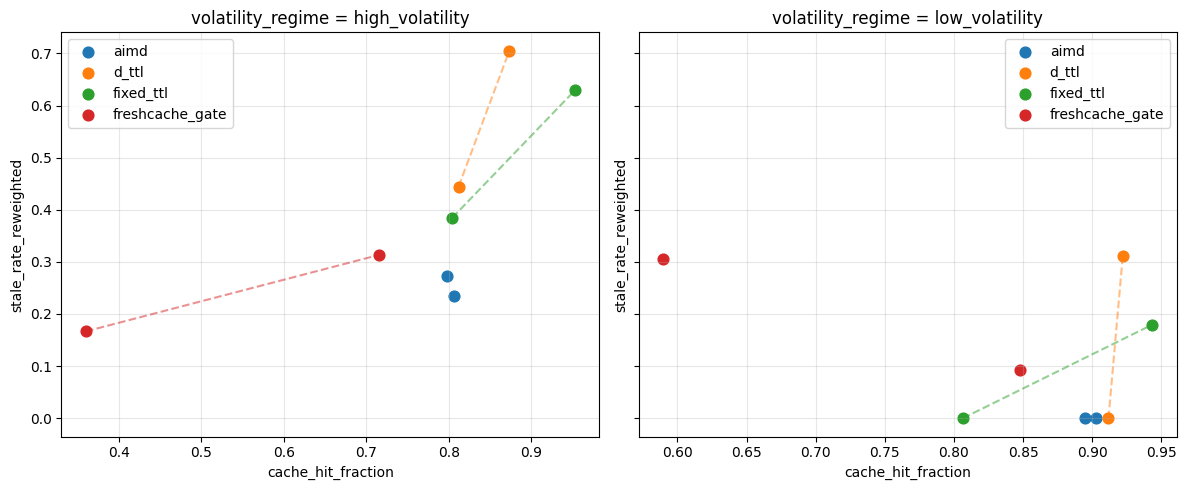

In [12]:
verdict = result["_full_detail"]["verdict"]
print("=== VERDICT ===")
print(json.dumps(verdict, indent=2))

op_df = pd.DataFrame(result["_full_detail"]["operating_points"])
print("\
=== Operating points (first 10) ===")
print(op_df[["policy", "knob_value", "volatility_regime", "n_calls", "cache_hit_fraction", "stale_rate_reweighted"]].head(10).to_string(index=False))

conv_summ_df = pd.DataFrame(result["_full_detail"]["convergence_summary"])
print("\
=== Convergence summary ===")
print(conv_summ_df.to_string(index=False))

regimes = sorted(op_df["volatility_regime"].unique())
fig, axes = plt.subplots(1, len(regimes), figsize=(6 * len(regimes), 5), sharey=True)
if len(regimes) == 1:
    axes = [axes]
colors = plt.cm.tab10.colors
policy_list = sorted(op_df["policy"].unique())
policy_color = {p: colors[i % len(colors)] for i, p in enumerate(policy_list)}

for ax, regime in zip(axes, regimes):
    sub = op_df[op_df.volatility_regime == regime]
    for policy in policy_list:
        p_sub = sub[sub.policy == policy].sort_values("cache_hit_fraction")
        if len(p_sub) == 0:
            continue
        ax.scatter(p_sub["cache_hit_fraction"], p_sub["stale_rate_reweighted"], label=policy, color=policy_color[policy], s=60)
        nd = result["_full_detail"]["pareto_frontiers"].get(regime, {}).get(policy, {}).get("non_dominated_points", [])
        if len(nd) > 1:
            nd_sorted = sorted(nd, key=lambda t: t[0])
            ax.plot([p[0] for p in nd_sorted], [p[1] for p in nd_sorted], color=policy_color[policy], alpha=0.5, linestyle="--")
    ax.set_title(f"volatility_regime = {regime}")
    ax.set_xlabel("cache_hit_fraction")
    ax.set_ylabel("stale_rate_reweighted")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()